# 🩺 Symptom-Based Disease Prediction Using Neural Networks

## Project Goal
The goal of this project is to investigate whether a neural network can predict diseases from symptom data. The dataset contains 132 symptom features and 42 disease classes. Different neural-network architectures and regularization techniques will be tested and compared in order to improve prediction accuracy while reducing overfitting. 

This project will also include an ethical impact assessment because AI systems used in healthcare may affect fairness, transparency, privacy, and responsibility.

# Research Questions
## This project investigates the following questions:
1. Can a neural network accurately predict diseases from symptom data?
2. How do different neural-network architectures affect performance?
3. Can regularization techniques reduce overfitting?
4. What ethical risks arise when using AI for healthcare prediction?

# Hypotheses
1. A simple neural network should already achieve relatively high accuracy because symptom data is structured and categorical.
2. Larger networks may improve training accuracy but also increase overfitting.
3. Regularization techniques such as dropout and early stopping should improve validation performance.
4. Even highly accurate healthcare AI systems may still raise ethical concerns related to fairness, transparency, and responsibility.

In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import confusion_matrix, classification_report

In [ ]:
import os
os.getcwd()


In [3]:
# load datasets
train_df = pd.read_csv("Training.csv")
test_df = pd.read_csv("Testing.csv")

print("Training shape:", train_df.shape)
print("Testing shape:", test_df.shape)

Training shape: (4920, 134)
Testing shape: (42, 133)


In [6]:
print(train_df.columns[-5:])
print(test_df.columns[-5:])

Index(['blister', 'red_sore_around_nose', 'yellow_crust_ooze', 'prognosis',
       'Unnamed: 133'],
      dtype='object')
Index(['inflammatory_nails', 'blister', 'red_sore_around_nose',
       'yellow_crust_ooze', 'prognosis'],
      dtype='object')


In [8]:
train_df = train_df.drop(columns=["Unnamed: 133"])

In [10]:
print("Training shape:", train_df.shape)
print("Testing shape:", test_df.shape)

Training shape: (4920, 133)
Testing shape: (42, 133)


# Dataset Exploration and Cleaning
Before building neural networks, it is important to understand the structure and quality of the dataset. This includes:
- number of features
- number of disease classes
- class balance
- symptom distribution
- possible missing values

Understanding the dataset helps explain later model behavior, model limitations, and possible sources of bias.

During the initial inspection, the training dataset contained one extra column compared to the testing dataset. The extra column (Unnamed: 133) did not contain meaningful information and was removed to ensure both datasets had the same structure.
After cleaning:
- both datasets contain 133 columns
- 132 binary symptom features
- 1 target disease column (prognosis)

In [15]:
train_df.head()

,itching,skin_rash,nodal_skin_eruptions,continuous_sneezing,shivering,chills,joint_pain,stomach_pain,acidity,ulcers_on_tongue,...,blackheads,scurring,skin_peeling,silver_like_dusting,small_dents_in_nails,inflammatory_nails,blister,red_sore_around_nose,yellow_crust_ooze,prognosis
0,1,1,1,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,Fungal infection
1,0,1,1,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,Fungal infection
2,1,0,1,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,Fungal infection
3,1,1,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,Fungal infection
4,1,1,1,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,Fungal infection


In [17]:
train_df.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4920 entries, 0 to 4919
Columns: 133 entries, itching to prognosis
dtypes: int64(132), object(1)
memory usage: 5.0+ MB


In [19]:
print(train_df.isnull().sum().sum())

0


In [21]:
print(train_df["prognosis"].nunique())

41


In [23]:
print(train_df["prognosis"].unique())

['Fungal infection' 'Allergy' 'GERD' 'Chronic cholestasis' 'Drug Reaction'
 'Peptic ulcer diseae' 'AIDS' 'Diabetes ' 'Gastroenteritis'
 'Bronchial Asthma' 'Hypertension ' 'Migraine' 'Cervical spondylosis'
 'Paralysis (brain hemorrhage)' 'Jaundice' 'Malaria' 'Chicken pox'
 'Dengue' 'Typhoid' 'hepatitis A' 'Hepatitis B' 'Hepatitis C'
 'Hepatitis D' 'Hepatitis E' 'Alcoholic hepatitis' 'Tuberculosis'
 'Common Cold' 'Pneumonia' 'Dimorphic hemmorhoids(piles)' 'Heart attack'
 'Varicose veins' 'Hypothyroidism' 'Hyperthyroidism' 'Hypoglycemia'
 'Osteoarthristis' 'Arthritis' '(vertigo) Paroymsal  Positional Vertigo'
 'Acne' 'Urinary tract infection' 'Psoriasis' 'Impetigo']


# Initial Dataset Observations
The dataset contains:
- 4920 patient samples
- 132 binary symptom features
- 41 disease classes stored in the prognosis column

The symptom features are represented as binary values:
- 1 indicates the presence of a symptom
- 0 indicates the absence of a symptom
  
No missing values were detected in the dataset, meaning no additional preprocessing for missing data was required.

Some disease labels contain inconsistent formatting, for example:

- trailing spaces (Diabetes , Hypertension )

- capitalization inconsistencies (hepatitis A)

- spelling inconsistencies (Peptic ulcer diseae)


In [33]:
train_df["prognosis"] = train_df["prognosis"].str.strip()
test_df["prognosis"] = test_df["prognosis"].str.strip()

In [35]:
print(train_df["prognosis"].nunique())

41


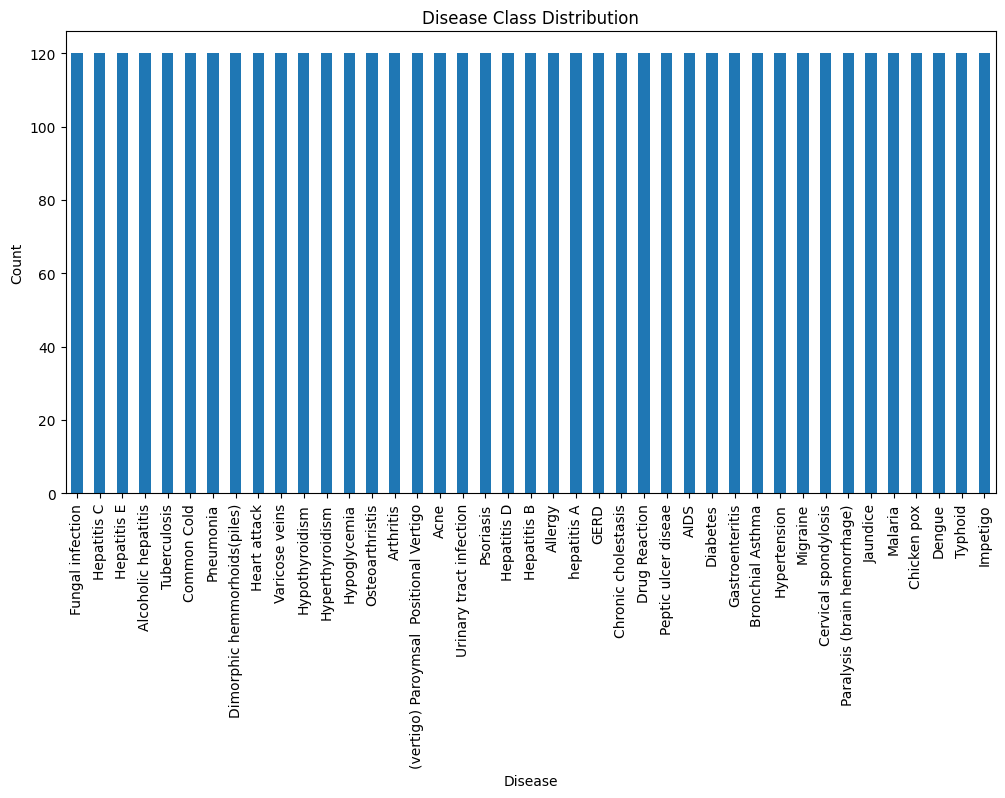

In [37]:
disease_counts = train_df["prognosis"].value_counts()

plt.figure(figsize=(12,6))

disease_counts.plot(kind="bar")

plt.title("Disease Class Distribution")
plt.xlabel("Disease")
plt.ylabel("Count")

plt.xticks(rotation=90)

plt.show()

# Disease Distribution Analysis
The disease distribution appears highly balanced, since each disease class contains approximately the same number of samples. This is beneficial for multi-class classification because the neural network is less likely to become biased toward a small subset of dominant classes.

Class imbalance is a common problem in medical machine learning datasets, where some diseases may occur much more frequently than others. In this dataset, the balanced distribution reduces the need for additional balancing techniques such as oversampling or class weighting.

A balanced dataset also makes evaluation metrics such as accuracy, precision, recall, and F1-score more reliable and easier to interpret.

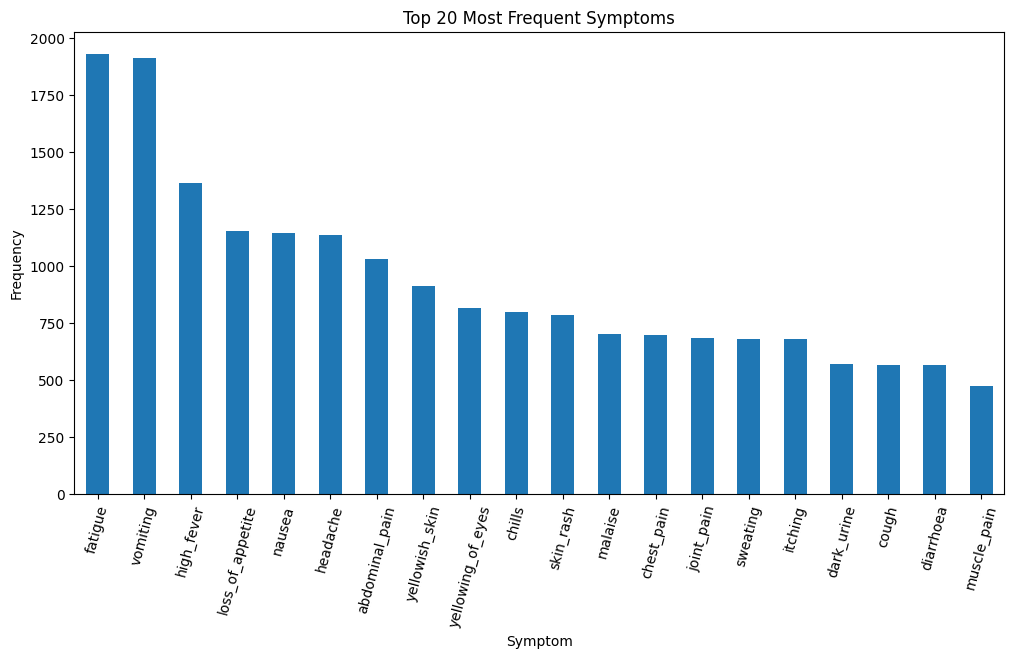

In [39]:
    symptom_counts = train_df.drop("prognosis", axis=1).sum().sort_values(ascending=False)

plt.figure(figsize=(12,6))

symptom_counts.head(20).plot(kind="bar")

plt.title("Top 20 Most Frequent Symptoms")
plt.xlabel("Symptom")
plt.ylabel("Frequency")

plt.xticks(rotation=75)

plt.show()

# Symptom Frequency Analysis
The symptom frequency distribution shows that some symptoms occur much more frequently than others. Symptoms such as fatigue, vomiting, and high fever appear in many disease classes, while other symptoms are much rarer.

This is important because highly frequent symptoms may contribute more strongly during training, while rare symptoms may be more difficult for the neural network to learn effectively.
                                                                                                                                          
The distribution also suggests that certain symptoms are less disease-specific and may appear across multiple conditions. This increases the complexity of the classification problem because the neural network must learn combinations of symptoms rather than relying on a single symptom alone.
    
The presence of overlapping symptoms between diseases reflects a realistic medical diagnostic setting, where multiple diseases may share similar clinical patterns.

# Data Preprocessing
Before training neural networks, the categorical disease labels must be converted into numerical form. Neural networks cannot directly process textual class labels, so label encoding is used to transform disease names into integer representations.
The dataset is also separated into:
- input features (symptoms)
- target labels (diseases)

Finally, the data is split into training and validation sets in order to evaluate model generalization and monitor overfitting during training.

In [48]:
# separate features and labels
X = train_df.drop("prognosis", axis=1)
y = train_df["prognosis"]

# encode disease labels into integers
label_encoder = LabelEncoder()
y_encoded = label_encoder.fit_transform(y)

# train-validation split
X_train, X_val, y_train, y_val = train_test_split(
    X,
    y_encoded,
    test_size=0.2,
    random_state=42,
    stratify=y_encoded
)

print("Training set:", X_train.shape)
print("Validation set:", X_val.shape)

Training set: (3936, 132)
Validation set: (984, 132)


# Baseline Neural Network
The first model acts as a baseline fully connected neural network for disease classification.

The purpose of the baseline model is to establish a reference point before introducing more advanced regularization and optimization techniques.
This model uses:
- fully connected dense layers
- ReLU activation
- Adam optimizer
- no dropout or explicit regularization

The model is kept relatively simple on purpose in order to evaluate how well a standard neural network can learn symptom–disease relationships.

In [54]:
# number of disease classes
num_classes = len(label_encoder.classes_)

# build baseline model
baseline_model = keras.Sequential([
    
    layers.Input(shape=(132,)),
    
    layers.Dense(128, activation="relu"),
    layers.Dense(64, activation="relu"),
    
    layers.Dense(num_classes, activation="softmax")
])

# compile model
baseline_model.compile(
    optimizer="adam",
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"]
)

# summary
baseline_model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 128)            │        17,024 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 41)             │         2,665 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 27,945 (109.16 KB)

 Trainable params: 27,945 (109.16 KB)

 Non-trainable params: 0 (0.00 B)

In [56]:
# train baseline model
history_baseline = baseline_model.fit(
    X_train,
    y_train,
    validation_data=(X_val, y_val),
    epochs=40,
    batch_size=32,
    verbose=1
)

Epoch 1/40
123/123 ━━━━━━━━━━━━━━━━━━━━ 1s 1ms/step - accuracy: 0.7812 - loss: 1.9466 - val_accuracy: 1.0000 - val_loss: 0.2276
Epoch 2/40
123/123 ━━━━━━━━━━━━━━━━━━━━ 0s 690us/step - accuracy: 1.0000 - loss: 0.0684 - val_accuracy: 1.0000 - val_loss: 0.0244
Epoch 3/40
123/123 ━━━━━━━━━━━━━━━━━━━━ 0s 765us/step - accuracy: 1.0000 - loss: 0.0147 - val_accuracy: 1.0000 - val_loss: 0.0100
Epoch 4/40
123/123 ━━━━━━━━━━━━━━━━━━━━ 0s 814us/step - accuracy: 1.0000 - loss: 0.0071 - val_accuracy: 1.0000 - val_loss: 0.0056
Epoch 5/40
123/123 ━━━━━━━━━━━━━━━━━━━━ 0s 749us/step - accuracy: 1.0000 - loss: 0.0042 - val_accuracy: 1.0000 - val_loss: 0.0037
Epoch 6/40
123/123 ━━━━━━━━━━━━━━━━━━━━ 0s 761us/step - accuracy: 1.0000 - loss: 0.0028 - val_accuracy: 1.0000 - val_loss: 0.0026
Epoch 7/40
123/123 ━━━━━━━━━━━━━━━━━━━━ 0s 741us/step - accuracy: 1.0000 - loss: 0.0021 - val_accuracy: 1.0000 - val_loss: 0.0019
Epoch 8/40
123/123 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - accuracy: 1.0000 - loss: 0.0015 - val_

# Baseline Model Results
The baseline neural network achieved extremely high training and validation accuracy, approaching 100%.

This suggests that the symptom patterns in the dataset are highly separable and that many diseases can be distinguished effectively from the available symptom combinations.

The rapid convergence of the model also indicates that the dataset contains strong predictive relationships between symptoms and disease labels.
    
However, such near-perfect performance may also indicate that the dataset is relatively simplified compared to real-world medical diagnosis settings, where symptom overlap, missing information, and noisy labels are much more common.

# Training Curve Visualization
Training and validation curves help visualize how the neural network learns over time.
They can reveal:
- convergence behavior
- underfitting
- overfitting
- training stability

In this experiment, the curves are used to evaluate how quickly the model learns symptom–disease relationships and whether the model generalizes consistently to unseen validation data.

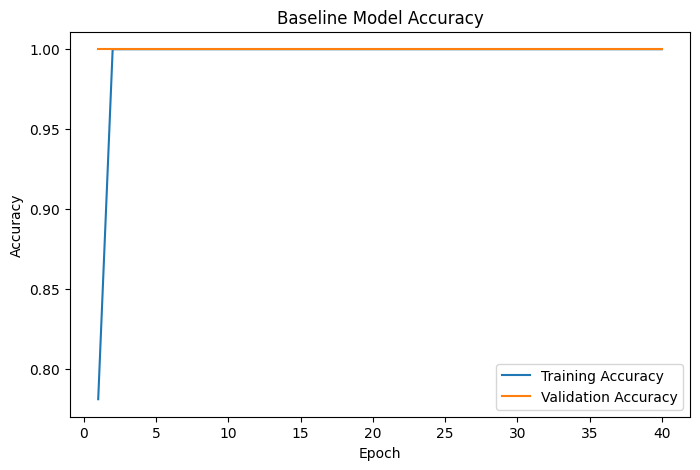

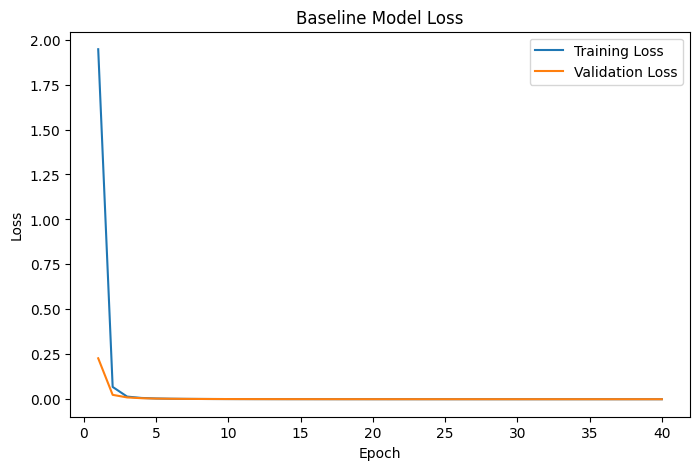

In [60]:
# extract history
history_dict = history_baseline.history

train_acc = history_dict["accuracy"]
val_acc = history_dict["val_accuracy"]

train_loss = history_dict["loss"]
val_loss = history_dict["val_loss"]

epochs = range(1, len(train_acc) + 1)

# accuracy plot
plt.figure(figsize=(8,5))

plt.plot(epochs, train_acc, label="Training Accuracy")
plt.plot(epochs, val_acc, label="Validation Accuracy")

plt.title("Baseline Model Accuracy")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")

plt.legend()
plt.show()

# loss plot
plt.figure(figsize=(8,5))

plt.plot(epochs, train_loss, label="Training Loss")
plt.plot(epochs, val_loss, label="Validation Loss")

plt.title("Baseline Model Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")

plt.legend()
plt.show()

# Training Curve Interpretation
The training and validation curves demonstrate extremely rapid convergence of the neural network. Accuracy approaches 100% after only a few epochs, while the loss decreases sharply toward near-zero values.

The validation curves closely follow the training curves throughout training, indicating very limited overfitting. This suggests that the model generalizes consistently to unseen validation samples within this dataset.
    
The smooth decrease in loss also indicates stable optimization behavior using the Adam optimizer and ReLU activations.

# Model Evaluation
Although overall accuracy is important, medical classification systems should also be evaluated at the class level.

Different diseases may have different prediction performance, and incorrect predictions could potentially lead to harmful outcomes in real medical settings.
    
Therefore, additional evaluation metrics such as confusion matrices and classification reports are used to better understand model behavior across disease classes.

In [64]:
# prepare test data
X_test = test_df.drop("prognosis", axis=1)
y_test = test_df["prognosis"]

# encode test labels
y_test_encoded = label_encoder.transform(y_test)

# evaluate baseline model
test_loss, test_acc = baseline_model.evaluate(X_test, y_test_encoded)

print("Test Accuracy:", test_acc)
print("Test Loss:", test_loss)

2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - accuracy: 0.9762 - loss: 0.0402     
Test Accuracy: 0.976190447807312
Test Loss: 0.04021717980504036


In [66]:
# predict disease classes
y_pred_probs = baseline_model.predict(X_test)

# convert probabilities to class labels
y_pred = np.argmax(y_pred_probs, axis=1)

2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 22ms/step


In [68]:
print(classification_report(
    y_test_encoded,
    y_pred,
    target_names=label_encoder.classes_
))

                                         precision    recall  f1-score   support

(vertigo) Paroymsal  Positional Vertigo       1.00      1.00      1.00         1
                                   AIDS       1.00      1.00      1.00         1
                                   Acne       1.00      1.00      1.00         1
                    Alcoholic hepatitis       1.00      1.00      1.00         1
                                Allergy       1.00      1.00      1.00         1
                              Arthritis       1.00      1.00      1.00         1
                       Bronchial Asthma       1.00      1.00      1.00         1
                   Cervical spondylosis       1.00      1.00      1.00         1
                            Chicken pox       1.00      1.00      1.00         1
                    Chronic cholestasis       1.00      1.00      1.00         1
                            Common Cold       1.00      1.00      1.00         1
                           

/opt/anaconda3/envs/tf-env/lib/python3.10/site-packages/sklearn/metrics/_classification.py:98: UserWarning: The number of unique classes is greater than 50% of the number of samples. `y` could represent a regression problem, not a classification problem.
  type_true = type_of_target(y_true, input_name="y_true")
/opt/anaconda3/envs/tf-env/lib/python3.10/site-packages/sklearn/metrics/_classification.py:99: UserWarning: The number of unique classes is greater than 50% of the number of samples. `y` could represent a regression problem, not a classification problem.
  type_pred = type_of_target(y_pred, input_name="y_pred")
/opt/anaconda3/envs/tf-env/lib/python3.10/site-packages/sklearn/utils/multiclass.py:79: UserWarning: The number of unique classes is greater than 50% of the number of samples. `y` could represent a regression problem, not a classification problem.
  ys_types = set(type_of_target(x) for x in ys)
/opt/anaconda3/envs/tf-env/lib/python3.10/site-packages/sklearn/utils/multicla

/opt/anaconda3/envs/tf-env/lib/python3.10/site-packages/sklearn/metrics/_classification.py:98: UserWarning: The number of unique classes is greater than 50% of the number of samples. `y` could represent a regression problem, not a classification problem.
  type_true = type_of_target(y_true, input_name="y_true")
/opt/anaconda3/envs/tf-env/lib/python3.10/site-packages/sklearn/metrics/_classification.py:99: UserWarning: The number of unique classes is greater than 50% of the number of samples. `y` could represent a regression problem, not a classification problem.
  type_pred = type_of_target(y_pred, input_name="y_pred")
/opt/anaconda3/envs/tf-env/lib/python3.10/site-packages/sklearn/utils/multiclass.py:79: UserWarning: The number of unique classes is greater than 50% of the number of samples. `y` could represent a regression problem, not a classification problem.
  ys_types = set(type_of_target(x) for x in ys)
/opt/anaconda3/envs/tf-env/lib/python3.10/site-packages/sklearn/utils/multicla

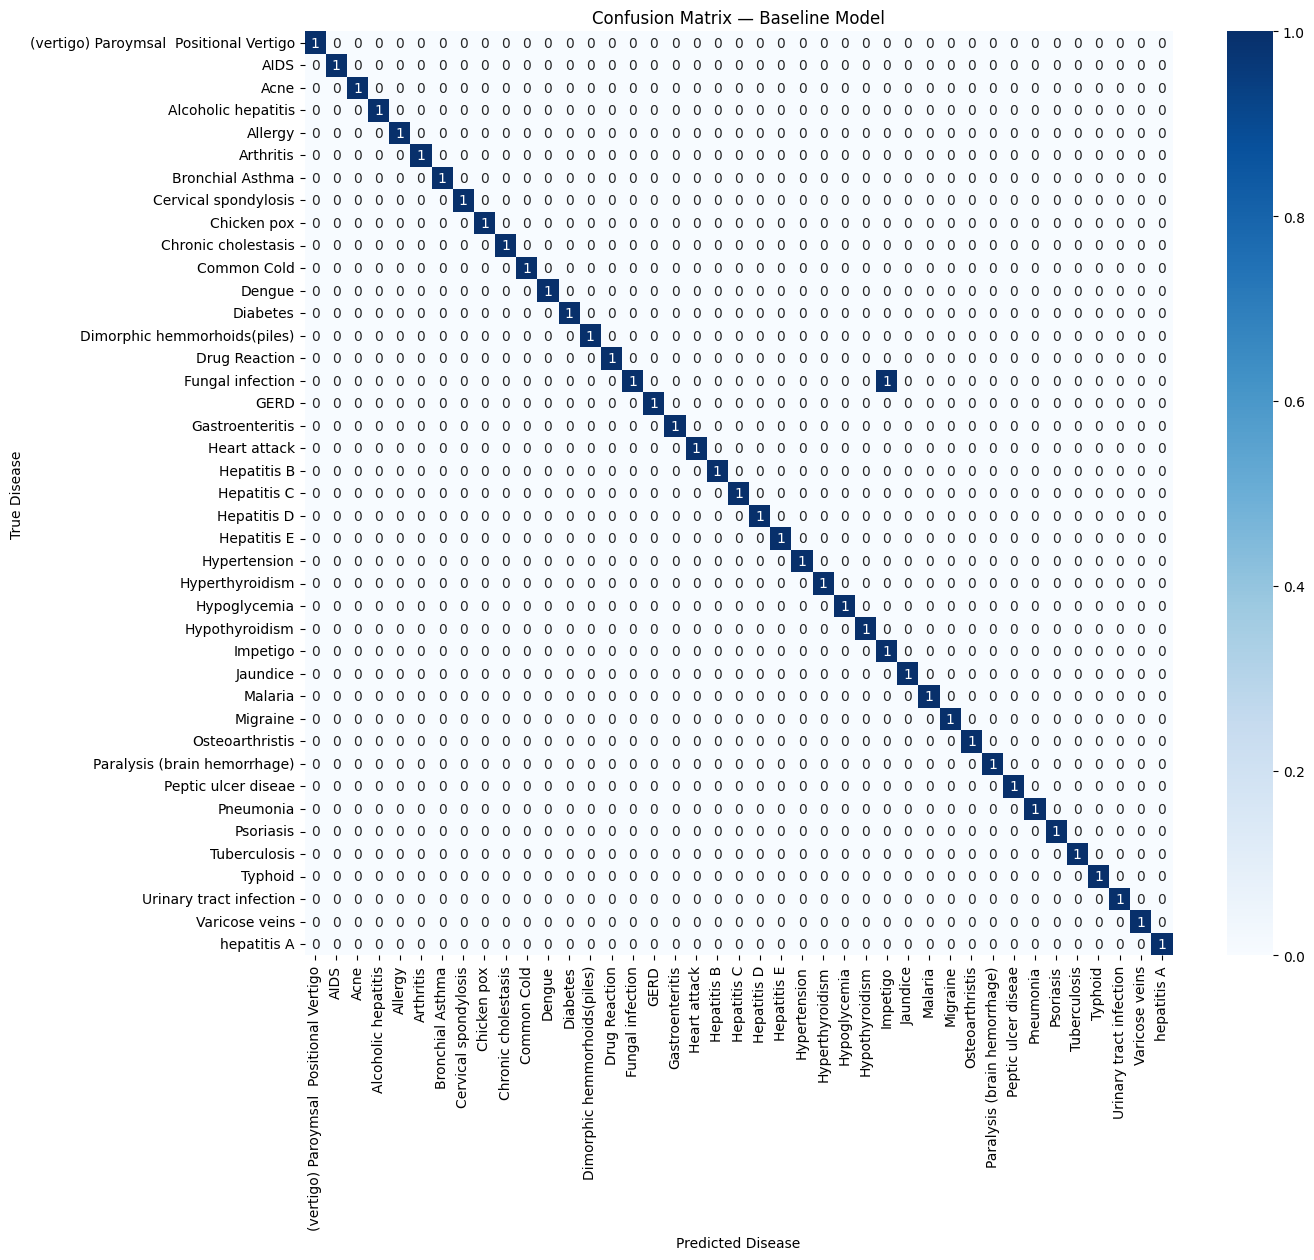

In [ ]:
# create confusion matrix
cm = confusion_matrix(y_test_encoded, y_pred)

plt.figure(figsize=(14,12))

sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=label_encoder.classes_,
    yticklabels=label_encoder.classes_
)

plt.title("Confusion Matrix — Baseline Model")
plt.xlabel("Predicted Disease")
plt.ylabel("True Disease")

plt.xticks(rotation=90)
plt.yticks(rotation=0)

plt.show()

# Confusion Matrix Interpretation
The confusion matrix shows that the neural network correctly classified the majority of disease classes. Most predictions appear along the diagonal, indicating strong classification performance across the dataset.
    
However, a small number of misclassifications are still present. This suggests that certain diseases may share similar symptom patterns, making them more difficult to distinguish based only on symptom input.

In real medical settings, symptom overlap between diseases is common, and incorrect predictions could potentially lead to harmful outcomes if used without human supervision.
    
The confusion matrix therefore highlights both the strengths and limitations of symptom-based neural network prediction systems.

# Ethical Reflection on Baseline Results
Although the neural network achieves very high accuracy, medical AI systems should not be evaluated using accuracy alone.
    
Even a small number of incorrect predictions may have serious consequences in healthcare applications. Misclassification of diseases could potentially delay treatment, increase patient anxiety, or result in inappropriate medical decisions.

This relates directly to the AI ethics principles of:
- non-maleficence (avoiding harm)
- esponsibility
- transparency

The model should therefore be considered a decision-support tool rather than a replacement for professional medical diagnosis.

# Controlled Experimentation Strategy
Instead of changing many hyperparameters simultaneously, the experiments in this project are designed as controlled modifications of the baseline model.
    
This approach makes it easier to understand which architectural changes influence performance.
    
The experiments are structured as follows:
- Baseline Model:
Simple fully connected neural network used as a reference.
- Regularized Model:
Adds dropout and early stopping to investigate whether regularization improves generalization and reduces overfitting.
- Deeper Model:
Increases network depth and capacity to examine whether more complex feature representations improve classification performance.

This experimental design allows clearer comparison between models.

# Model 2 — Regularized Neural Network

The baseline model already achieved very high accuracy. However, in medical AI systems, it is important to test whether the model generalizes reliably and does not simply memorize training patterns.

In this second experiment, we keep the architecture mostly similar to the baseline model, but add regularization techniques:

- Dropout
- EarlyStopping

Dropout randomly disables some neurons during training, which can reduce overfitting by forcing the network to learn more robust patterns.

EarlyStopping stops training when validation loss no longer improves, which prevents unnecessary training after the model has already learned the main patterns.

Hypothesis:  
The regularized model should achieve similar test accuracy to the baseline model, but with better protection against overfitting.

In [78]:
regularized_model = keras.Sequential([
    layers.Input(shape=(132,)),
    
    layers.Dense(128, activation="relu"),
    layers.Dropout(0.2),
    
    layers.Dense(64, activation="relu"),
    layers.Dropout(0.2),
    
    layers.Dense(num_classes, activation="softmax")
])

regularized_model.compile(
    optimizer="adam",
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"]
)

regularized_model.summary()

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_3 (Dense)                 │ (None, 128)            │        17,024 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 41)             │         2,665 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 27,945 (109.16 KB)

 Trainable params: 27,945 (109.16 KB)

 Non-trainable params: 0 (0.00 B)

In [80]:
early_stop = keras.callbacks.EarlyStopping(
    monitor="val_loss",
    patience=5,
    restore_best_weights=True
)

In [82]:
history_regularized = regularized_model.fit(
    X_train,
    y_train,
    validation_data=(X_val, y_val),
    epochs=40,
    batch_size=32,
    callbacks=[early_stop],
    verbose=1
)

Epoch 1/40
123/123 ━━━━━━━━━━━━━━━━━━━━ 1s 1ms/step - accuracy: 0.6192 - loss: 2.3628 - val_accuracy: 0.9980 - val_loss: 0.4913
Epoch 2/40
123/123 ━━━━━━━━━━━━━━━━━━━━ 0s 730us/step - accuracy: 0.9896 - loss: 0.2431 - val_accuracy: 1.0000 - val_loss: 0.0291
Epoch 3/40
123/123 ━━━━━━━━━━━━━━━━━━━━ 0s 750us/step - accuracy: 0.9975 - loss: 0.0606 - val_accuracy: 1.0000 - val_loss: 0.0082
Epoch 4/40
123/123 ━━━━━━━━━━━━━━━━━━━━ 0s 745us/step - accuracy: 0.9985 - loss: 0.0315 - val_accuracy: 1.0000 - val_loss: 0.0035
Epoch 5/40
123/123 ━━━━━━━━━━━━━━━━━━━━ 0s 764us/step - accuracy: 0.9997 - loss: 0.0182 - val_accuracy: 1.0000 - val_loss: 0.0022
Epoch 6/40
123/123 ━━━━━━━━━━━━━━━━━━━━ 0s 736us/step - accuracy: 0.9995 - loss: 0.0143 - val_accuracy: 1.0000 - val_loss: 0.0012
Epoch 7/40
123/123 ━━━━━━━━━━━━━━━━━━━━ 0s 743us/step - accuracy: 0.9997 - loss: 0.0110 - val_accuracy: 1.0000 - val_loss: 8.4139e-04
Epoch 8/40
123/123 ━━━━━━━━━━━━━━━━━━━━ 0s 928us/step - accuracy: 0.9997 - loss: 0.0082 

In [84]:
test_loss_reg, test_acc_reg = regularized_model.evaluate(X_test, y_test_encoded)

print("Regularized Model Test Accuracy:", test_acc_reg)
print("Regularized Model Test Loss:", test_loss_reg)

2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.9762 - loss: 0.0914    
Regularized Model Test Accuracy: 0.976190447807312
Regularized Model Test Loss: 0.09141511470079422


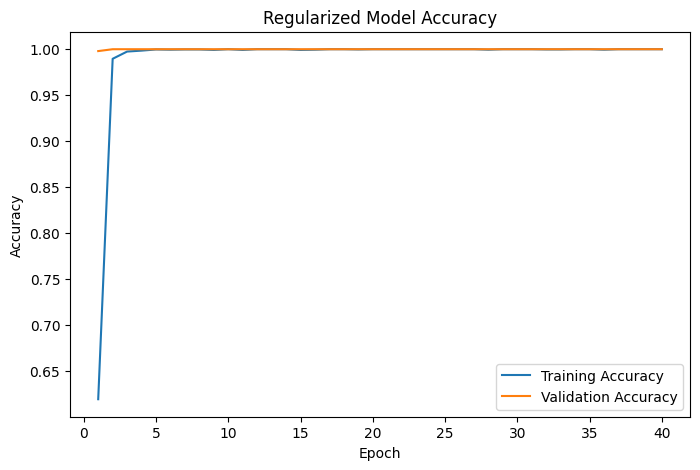

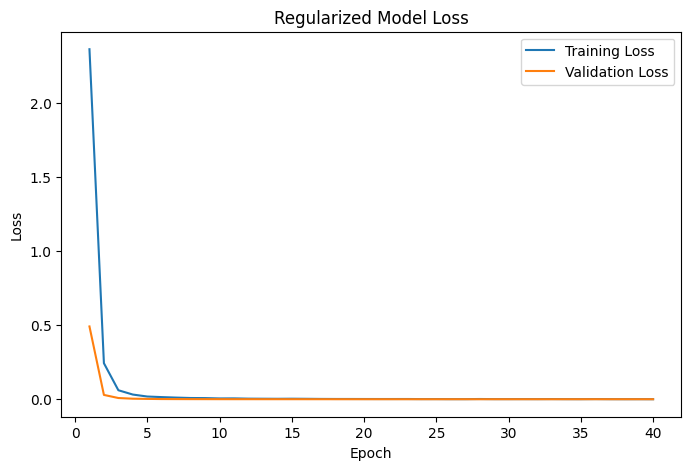

In [86]:
history_dict = history_regularized.history

train_acc = history_dict["accuracy"]
val_acc = history_dict["val_accuracy"]

train_loss = history_dict["loss"]
val_loss = history_dict["val_loss"]

epochs = range(1, len(train_acc) + 1)

plt.figure(figsize=(8,5))
plt.plot(epochs, train_acc, label="Training Accuracy")
plt.plot(epochs, val_acc, label="Validation Accuracy")
plt.title("Regularized Model Accuracy")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.legend()
plt.show()

plt.figure(figsize=(8,5))
plt.plot(epochs, train_loss, label="Training Loss")
plt.plot(epochs, val_loss, label="Validation Loss")
plt.title("Regularized Model Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.legend()
plt.show()

For the regularized model, the training and validation curves should be interpreted carefully because dropout is active during training but inactive during validation and testing. This means that training accuracy can sometimes appear lower than validation accuracy, even when the model generalizes well.

# Regularized Model Interpretation
The regularized model achieved nearly identical test accuracy compared to the baseline model. This suggests that the disease classes in the dataset are already highly separable using the available symptom features.

Although dropout and early stopping are commonly used to reduce overfitting, they did not significantly improve generalization performance in this experiment.
    
The regularized model produced slightly higher test loss than the baseline model. One possible explanation is that the dataset is relatively structured and simple, meaning the baseline model was already capable of learning stable decision boundaries without severe overfitting.

This experiment demonstrates that regularization techniques are not always guaranteed to improve performance and should be evaluated empirically rather than assumed to help automatically.

# Ethical Reflection on Model Reliability
The regularized model demonstrates stable and reliable performance across the validation and testing sets. In medical AI systems, reliability and consistent generalization are especially important because incorrect predictions could negatively affect patient decisions.
    
Even though regularization did not improve accuracy significantly in this dataset, techniques such as dropout and early stopping remain important safeguards in larger and more complex healthcare systems where overfitting could lead to unsafe predictions on unseen patients.
    
This relates directly to the ethical principle of non-maleficence, which emphasizes minimizing harm caused by AI systems.

# Model 3 — Deeper Neural Network
In the third experiment, we investigate whether increasing the depth and capacity of the neural network improves disease prediction performance.
    
Deeper neural networks can potentially learn more complex relationships between symptoms and diseases by building hierarchical feature representations across multiple hidden layers.

However, deeper models may also increase the risk of overfitting and training instability.

To keep the experiment controlled, the optimizer and activation functions remain mostly unchanged while the network depth is increased.

Hypothesis:
A deeper network may improve classification performance slightly, but may also increase the risk of overfitting due to the relatively small dataset size.

In [95]:
deep_model = keras.Sequential([
    layers.Input(shape=(132,)),
    
    layers.Dense(256, activation="relu"),
    layers.Dense(128, activation="relu"),
    layers.Dense(64, activation="relu"),
    
    layers.Dense(num_classes, activation="softmax")
])

deep_model.compile(
    optimizer="adam",
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"]
)

deep_model.summary()

Model: "sequential_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_6 (Dense)                 │ (None, 256)            │        34,048 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_7 (Dense)                 │ (None, 128)            │        32,896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_8 (Dense)                 │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_9 (Dense)                 │ (None, 41)             │         2,665 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 77,865 (304.16 KB)

 Trainable params: 77,865 (304.16 KB)

 Non-trainable params: 0 (0.00 B)

In [97]:
history_deep = deep_model.fit(
    X_train,
    y_train,
    validation_data=(X_val, y_val),
    epochs=40,
    batch_size=32,
    callbacks=[early_stop],
    verbose=1
)

Epoch 1/40
123/123 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.8410 - loss: 1.2374 - val_accuracy: 1.0000 - val_loss: 0.0188
Epoch 2/40
123/123 ━━━━━━━━━━━━━━━━━━━━ 0s 951us/step - accuracy: 1.0000 - loss: 0.0081 - val_accuracy: 1.0000 - val_loss: 0.0049
Epoch 3/40
123/123 ━━━━━━━━━━━━━━━━━━━━ 0s 930us/step - accuracy: 1.0000 - loss: 0.0032 - val_accuracy: 1.0000 - val_loss: 0.0022
Epoch 4/40
123/123 ━━━━━━━━━━━━━━━━━━━━ 0s 893us/step - accuracy: 1.0000 - loss: 0.0015 - val_accuracy: 1.0000 - val_loss: 0.0013
Epoch 5/40
123/123 ━━━━━━━━━━━━━━━━━━━━ 0s 890us/step - accuracy: 1.0000 - loss: 9.2009e-04 - val_accuracy: 1.0000 - val_loss: 8.4926e-04


In [99]:
test_loss_deep, test_acc_deep = deep_model.evaluate(X_test, y_test_encoded)

print("Deep Model Test Accuracy:", test_acc_deep)
print("Deep Model Test Loss:", test_loss_deep)

2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - accuracy: 0.9762 - loss: 0.0641 
Deep Model Test Accuracy: 0.976190447807312
Deep Model Test Loss: 0.06405995041131973


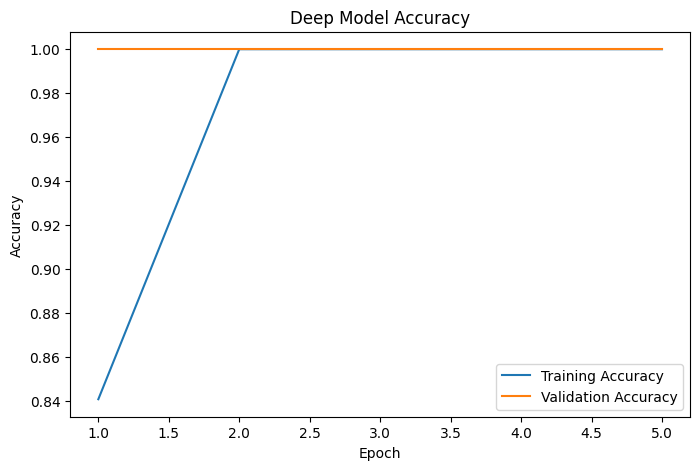

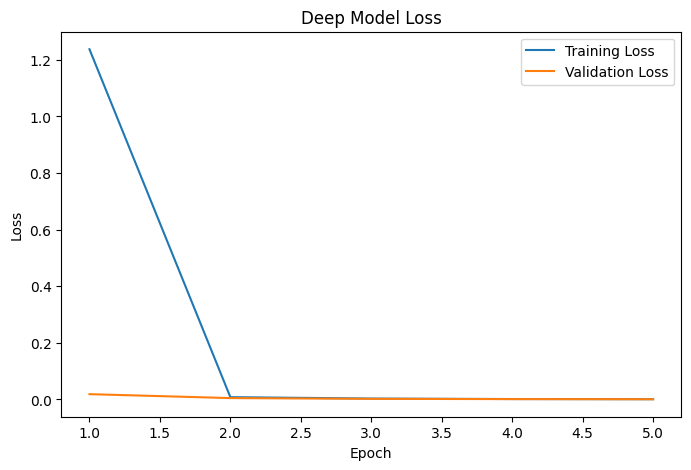

In [101]:
history_dict = history_deep.history

train_acc = history_dict["accuracy"]
val_acc = history_dict["val_accuracy"]

train_loss = history_dict["loss"]
val_loss = history_dict["val_loss"]

epochs = range(1, len(train_acc) + 1)

plt.figure(figsize=(8,5))
plt.plot(epochs, train_acc, label="Training Accuracy")
plt.plot(epochs, val_acc, label="Validation Accuracy")
plt.title("Deep Model Accuracy")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.legend()
plt.show()

plt.figure(figsize=(8,5))
plt.plot(epochs, train_loss, label="Training Loss")
plt.plot(epochs, val_loss, label="Validation Loss")
plt.title("Deep Model Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.legend()
plt.show()

# Deep Model Interpretation
The deeper neural network achieved the same test accuracy as the baseline and regularized models. This suggests that increasing model depth and capacity did not improve classification performance for this dataset.
    
Although the deep model contains more trainable parameters, the dataset appears already highly separable using a simpler architecture. Therefore, the additional capacity did not provide a clear benefit.
    
The model converged very quickly, reaching perfect validation accuracy after only a few epochs. This supports the earlier observation that the symptom-disease relationships in this dataset are highly structured.

However, the deeper model also has more parameters, which may increase computational cost and potential overfitting risk in more complex or noisy real-world datasets.

## Since the baseline model achieved the same test accuracy with lower loss and fewer parameters, it was selected as the preferred model.

# Model Comparison

After training all three neural networks, their test-set performance was compared. This comparison helps determine whether increased model complexity or regularization improved the final prediction performance.

In [106]:
results = pd.DataFrame([
    {
        "Model": "Baseline",
        "Architecture": "Dense(128) → Dense(64)",
        "Regularization": "None",
        "Test Accuracy": test_acc,
        "Test Loss": test_loss,
        "Parameters": baseline_model.count_params()
    },
    {
        "Model": "Regularized",
        "Architecture": "Dense(128) → Dropout → Dense(64) → Dropout",
        "Regularization": "Dropout + EarlyStopping",
        "Test Accuracy": test_acc_reg,
        "Test Loss": test_loss_reg,
        "Parameters": regularized_model.count_params()
    },
    {
        "Model": "Deep",
        "Architecture": "Dense(256) → Dense(128) → Dense(64)",
        "Regularization": "EarlyStopping",
        "Test Accuracy": test_acc_deep,
        "Test Loss": test_loss_deep,
        "Parameters": deep_model.count_params()
    }
])

results

,Model,Architecture,Regularization,Test Accuracy,Test Loss,Parameters
0,Baseline,Dense(128) → Dense(64),None,0.97619,0.040217,27945
1,Regularized,Dense(128) → Dropout → Dense(64) → Dropout,Dropout + EarlyStopping,0.97619,0.091415,27945
2,Deep,Dense(256) → Dense(128) → Dense(64),EarlyStopping,0.97619,0.064060,77865


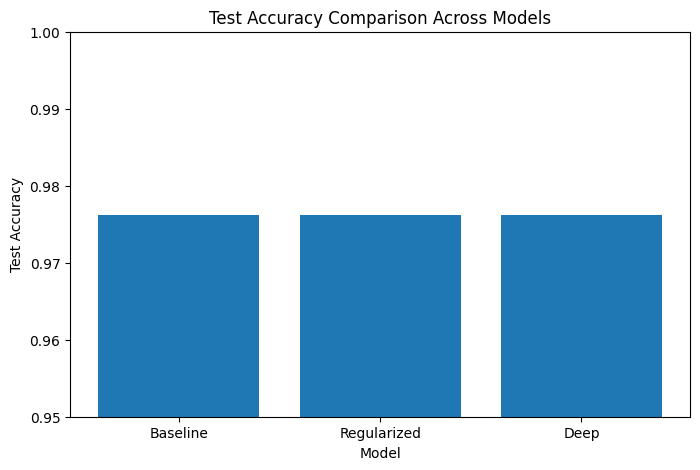

In [108]:
plt.figure(figsize=(8,5))

plt.bar(results["Model"], results["Test Accuracy"])

plt.title("Test Accuracy Comparison Across Models")
plt.xlabel("Model")
plt.ylabel("Test Accuracy")
plt.ylim(0.95, 1.0)

plt.show()

## Model Comparison Interpretation

All three neural networks achieved the same test accuracy of approximately 97.62%. This indicates that the dataset can be classified effectively using a relatively simple fully connected neural network.

The regularized and deeper models did not improve accuracy compared to the baseline model. The baseline model also achieved the lowest test loss, suggesting that it produced more confident and accurate probability estimates on the test set.

Based on these results, the baseline model was selected as the preferred model because it provides the best balance between performance, simplicity, and computational efficiency.

This result also demonstrates an important machine learning principle: increasing model complexity does not always improve performance, especially when the dataset is already highly structured and separable.

# Ethical Impact Assessment

This project uses a neural network to predict diseases from symptom data. Although the model achieved high accuracy, healthcare AI systems raise important ethical concerns.

## Transparency
Neural networks are difficult to interpret fully, so users may not understand why a specific disease prediction was made.

## Fairness
The dataset may not represent all demographic groups equally, which could reduce prediction quality for underrepresented populations.

## Non-maleficence
Incorrect predictions could potentially cause harm through delayed treatment, anxiety, or incorrect self-diagnosis. Therefore, the system should only be used as a supportive tool rather than a replacement for medical professionals.

## Responsibility
Human oversight is important when using AI in healthcare. Medical decisions should not rely entirely on automated predictions.

## Privacy
Medical symptom data is highly sensitive and would require strong privacy protection and secure storage in real-world applications.

Overall, this project demonstrates the potential of machine learning in healthcare, while also highlighting the importance of ethical considerations before deploying AI systems in real medical environments.

# Final Discussion

Three different neural-network configurations were tested for disease prediction from symptom data.

The baseline model already achieved very strong performance, showing that the symptom dataset contains highly informative patterns that are suitable for classification using fully connected neural networks.

The regularized model introduced dropout and weight decay in order to reduce overfitting and improve generalization. Although validation performance remained very high, the test accuracy stayed similar to the baseline model. This suggests that the dataset may already be relatively easy to separate due to the binary symptom representation.

The deeper model used additional layers and a more advanced architecture. Training converged extremely quickly and achieved perfect training and validation accuracy after only a few epochs. However, the test accuracy again remained close to the previous models. This indicates that increasing complexity did not significantly improve generalization performance for this dataset.

The experiments demonstrate an important machine learning principle: more complex neural networks do not always produce better real-world performance. Model complexity must match the difficulty and size of the dataset.

Another important observation is that the testing dataset is very small compared to the training dataset. This may limit the reliability of the final test evaluation and make performance estimates less stable.

Overall, the project demonstrates that neural networks can successfully learn relationships between symptoms and diseases, while also highlighting the importance of proper evaluation, regularization, and ethical considerations in healthcare AI systems.